Total rows with best_mass>0: 739
Rows with reject_null=True:  477


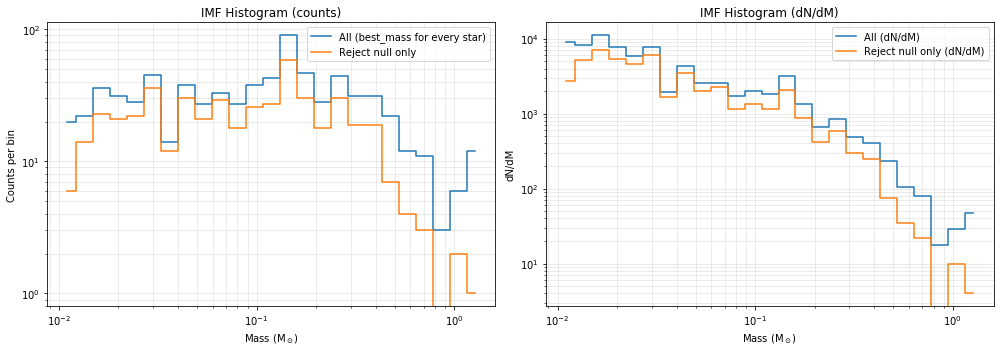

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load fit results ---
csv_path = "fit_results_jwst_hstall.csv"
df = pd.read_csv(csv_path)

# Basic sanity filtering
df = df.dropna(subset=["best_mass"])
df = df[df["best_mass"] > 0].copy()

# "Statistically significant" = we have a non-empty acceptable region
# (i.e., mass_min/mass_max/AV_min/AV_max were written)
df["reject_null"] = df[["mass_min","mass_max","AV_min","AV_max"]].notnull().all(axis=1)

m_all = df["best_mass"].values
m_sig = df.loc[df["reject_null"], "best_mass"].values

print(f"Total rows with best_mass>0: {len(m_all)}")
print(f"Rows with reject_null=True:  {len(m_sig)}")

# --- Choose IMF binning (log-spaced is standard) ---
m_min = max(0.01, np.nanmin(m_all))
m_max = np.nanmax(m_all)

# If your masses are very quantized (they are, from the interpolated grid),
# log bins still work fine for visualization.
nbins = 25
bins = np.logspace(np.log10(m_min), np.log10(m_max), nbins + 1)

# --- Histogram counts ---
N_all, edges = np.histogram(m_all, bins=bins)
N_sig, _     = np.histogram(m_sig, bins=bins)

bin_centers = np.sqrt(edges[:-1] * edges[1:])   # geometric mean for log bins
bin_widths  = edges[1:] - edges[:-1]

# Optional: convert to a "dN/dM" style (counts per unit mass)
dndm_all = N_all / bin_widths
dndm_sig = N_sig / bin_widths

# --- Plot IMF (two panels: counts and dN/dM) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: raw counts per bin
axes[0].step(bin_centers, N_all, where="mid", label="All (best_mass for every star)")
axes[0].step(bin_centers, N_sig, where="mid", label="Reject null only")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Mass (M$_\\odot$)")
axes[0].set_ylabel("Counts per bin")
axes[0].set_title("IMF Histogram (counts)")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

# Panel 2: dN/dM
axes[1].step(bin_centers, dndm_all, where="mid", label="All (dN/dM)")
axes[1].step(bin_centers, dndm_sig, where="mid", label="Reject null only (dN/dM)")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Mass (M$_\\odot$)")
axes[1].set_ylabel("dN/dM")
axes[1].set_title("IMF Histogram (dN/dM)")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()